In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.utils import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    journal_plot_pack,
)
from sklearn.preprocessing import StandardScaler

In [15]:
BASE_MODEL_DIR="../resources/models/real"
BASE_RESULTS_DIR="../resources/results/real"

# filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
# X, Y, cell_ids, rec_ids = load_data("../resources/data/simulated", filenames)

# Real data
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/Temi_Data.mat")

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((14, 1657180), (1657180,), (1657180,), (1657180,))

In [5]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== GLM Summary =====

--- Cell 1 ---
Train pseudo-R²:       0.0987
Train log-likelihood:  -4004.04
Train deviance:        1.48
Val pseudo-R²:         -0.0488
Val log-likelihood:    -896.92
Val deviance:          1.23
Test pseudo-R²:        -0.0148
Test log-likelihood:   -922.86
Test deviance:         1.23

--- Cell 2 ---
Train pseudo-R²:       0.1369
Train log-likelihood:  -3744.74
Train deviance:        0.92
Val pseudo-R²:         0.1577
Val log-likelihood:    -842.23
Val deviance:          0.93
Test pseudo-R²:        0.1213
Test log-likelihood:   -868.11
Test deviance:         0.94

--- Cell 3 ---
Train pseudo-R²:       0.1143
Train log-likelihood:  -3000.20
Train deviance:        0.78
Val pseudo-R²:         -0.1305
Val log-likelihood:    -959.03
Val deviance:          1.34
Test pseudo-R²:        -0.0526
Test log-likelihood:   -884.08
Test deviance:         1.08

--- Cell 4 ---
Train pseudo-R²:       0.1733
Train log-likelihood:  -3234.94
Train deviance:        1.26
Val pseudo-R²

In [6]:
glm_results["best_params"]

{1: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 2: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 4: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 5: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 6: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 7: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 8: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 9: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 10: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 11: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12: {'model_params': {'alpha': 0.0}, 'trainer_params': {}},
 13: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 15: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 16: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 17: {'model_params': {'alpha':

In [7]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": False, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== GLM Summary =====

--- Cell 1 ---
Train pseudo-R²:       0.1208
Train log-likelihood:  -3924.89
Train deviance:        1.45
Val metrics:           (not available)
Test pseudo-R²:        -0.0113
Test log-likelihood:   -1804.02
Test deviance:         1.21

--- Cell 2 ---
Train pseudo-R²:       0.1369
Train log-likelihood:  -3744.74
Train deviance:        0.92
Val metrics:           (not available)
Test pseudo-R²:        0.1400
Test log-likelihood:   -1710.34
Test deviance:         0.93

--- Cell 3 ---
Train pseudo-R²:       0.1143
Train log-likelihood:  -3000.20
Train deviance:        0.78
Val metrics:           (not available)
Test pseudo-R²:        -0.0921
Test log-likelihood:   -1843.11
Test deviance:         1.21

--- Cell 4 ---
Train pseudo-R²:       0.1733
Train log-likelihood:  -3234.94
Train deviance:        1.26
Val metrics:           (not available)
Test pseudo-R²:        -0.0142
Test log-likelihood:   -1893.51
Test deviance:         1.87

--- Cell 5 ---
Train pseudo-R²:

In [8]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== XGBoost Summary =====

--- Cell 1 ---
Train pseudo-R²:       0.3412
Train log-likelihood:  -3134.92
Train deviance:        1.08
Val pseudo-R²:         0.0009
Val log-likelihood:    -869.80
Val deviance:          1.17
Test pseudo-R²:        0.0535
Test log-likelihood:   -884.13
Test deviance:         1.15

--- Cell 2 ---
Train pseudo-R²:       0.2458
Train log-likelihood:  -3491.88
Train deviance:        0.80
Val pseudo-R²:         0.2375
Val log-likelihood:    -801.22
Val deviance:          0.84
Test pseudo-R²:        0.1779
Test log-likelihood:   -839.75
Test deviance:         0.88

--- Cell 3 ---
Train pseudo-R²:       0.3223
Train log-likelihood:  -2599.56
Train deviance:        0.60
Val pseudo-R²:         0.0995
Val log-likelihood:    -832.16
Val deviance:          1.06
Test pseudo-R²:        0.1436
Test log-likelihood:   -789.98
Test deviance:         0.88

--- Cell 4 ---
Train pseudo-R²:       0.4216
Train log-likelihood:  -2412.66
Train deviance:        0.88
Val pseudo-R²

In [9]:
xgboost_results["best_params"]

{1: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 2: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 3: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 4: {'model_params': {'learning_rate': 0.05,
   'max_depth': 4,
   'n_estimators': 200},
  'trainer_params': {}},
 5: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 6: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 7: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 8: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 9: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},

In [10]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": False},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== XGBoost Summary =====

--- Cell 1 ---
Train pseudo-R²:       0.4299
Train log-likelihood:  -2817.01
Train deviance:        0.94
Val metrics:           (not available)
Test pseudo-R²:        0.0297
Test log-likelihood:   -1758.19
Test deviance:         1.16

--- Cell 2 ---
Train pseudo-R²:       0.3281
Train log-likelihood:  -3300.81
Train deviance:        0.72
Val metrics:           (not available)
Test pseudo-R²:        0.1961
Test log-likelihood:   -1653.38
Test deviance:         0.87

--- Cell 3 ---
Train pseudo-R²:       0.4283
Train log-likelihood:  -2395.53
Train deviance:        0.50
Val metrics:           (not available)
Test pseudo-R²:        0.0332
Test log-likelihood:   -1713.67
Test deviance:         1.07

--- Cell 4 ---
Train pseudo-R²:       0.4620
Train log-likelihood:  -2278.81
Train deviance:        0.82
Val metrics:           (not available)
Test pseudo-R²:        0.1670
Test log-likelihood:   -1580.55
Test deviance:         1.54

--- Cell 5 ---
Train pseudo-R²

In [11]:
# Neural Network hyperparameter grids
nn_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

In [ ]:
# Per-cell Neural Network with grid search
nn_results = run_experiment(
    "NN-PerCell",
    fit_poisson_nn,
    {
        "batch_size": "auto",
        "epochs": 30,
        "grid_search": True,
        "k_folds": 2,
        "model_param_grid": nn_model_param_grid,
        "trainer_param_grid": nn_trainer_param_grid,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

In [ ]:
nn_results["best_params"]

{0.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 1.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 2.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.001}},
 3.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 4.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 10.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 11.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 12.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 13.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 14.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 25.0: {'model_params': {'hidden_sizes': (64, 32)},
  'tra

In [ ]:
# Per-cell Neural Network without grid search (for comparison)
nn_nogs_results = run_experiment(
    "NN-PerCell-NoGS",
    fit_poisson_nn,
    {
        "batch_size": "auto",
        "hidden_sizes": [64, 32],
        "l1_lambda": 0.0,
        "grid_search": False,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

Preparing datasets with train_frac=0.7, val_frac=0.15, use_val=True

=== Network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             384
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 32]           2,080
              ReLU-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
          Softplus-6                    [-1, 1]               0
Total params: 2,497
Trainable params: 2,497
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------
=== end architecture summary ===


=== Final network architecture su

In [ ]:
# Transfer Learning hyperparameter grids
tl_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
tl_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

In [ ]:
# Transfer Learning NN with grid search
nn_tl_results = run_experiment(
    "NN-TL",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": True,
        "model_param_grid": tl_model_param_grid,
        "trainer_param_grid": tl_trainer_param_grid,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== NN-TL Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2638
Test log-likelihood:   2411.14
Test deviance:         11.16

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1960
Test log-likelihood:   2021.01
Test deviance:         11.88

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2601
Test log-likelihood:   2031.09
Test deviance:         10.33

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2348
Test log-likelihood:   2086.90
Test deviance:         11.02

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1838
Test log-likelihood:   2035.71
Test deviance:         12.03

--- Cell 10.0 ---
Train metrics:         (

In [ ]:
nn_tl_results["best_params"]

{'model_params': {'hidden_sizes': (64, 32)},
 'trainer_params': {'l1_lambda': 0.0}}

In [ ]:
# Transfer Learning NN without grid search (for comparison)
nn_tl_nogs_results = run_experiment(
    "NN-TL-NoGS",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "hidden_sizes": (64, 32),
        "l1_lambda": 1e-4,
        "grid_search": False,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             384
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 32]           2,080
              ReLU-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
          Softplus-6                    [-1, 1]               0
SharedHiddenPoissonNN-7                       [-1]               0
Total params: 2,497
Trainable params: 2,497
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------
=== end architecture summa

In [ ]:
# Transfer Learning hyperparameter grids for SharedNonlinearHeadsPoissonNN
tl_model_param_grid_nonlinear = {
    "shared_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ],
    "head_sizes": [
        (32, 16),
        (64, 32),
    ],
}

tl_trainer_param_grid_nonlinear = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

In [ ]:
nn_tl_results_nonlinear = run_experiment(
    "NN-TL-NonlinearHeads",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": True,
        "model_type": "shared_nonlinear_heads",
        "model_param_grid": tl_model_param_grid_nonlinear,
        "trainer_param_grid": tl_trainer_param_grid_nonlinear,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== NN-TL-NonlinearHeads Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5394
Test log-likelihood:   3351.48
Test deviance:         6.98

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5716
Test log-likelihood:   3269.57
Test deviance:         6.33

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5647
Test log-likelihood:   2987.79
Test deviance:         6.08

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5699
Test log-likelihood:   3172.73
Test deviance:         6.19

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5679
Test log-likelihood:   3309.53
Test deviance:         6.37

--- Cell 10.0 ---
Train metrics:

In [ ]:
nn_tl_results_nonlinear["best_params"]

{'model_params': {'head_sizes': (64, 32), 'shared_sizes': (64,)},
 'trainer_params': {'l1_lambda': 1e-05}}

In [ ]:
# Transfer Learning NN (SharedNonlinearHeadsPoissonNN) without grid search
nn_tl_nogs_nonlinear = run_experiment(
    "NN-TL-NonlinearHeads-NoGS",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": False,
        "model_type": "shared_nonlinear_heads",
        "model_params": {
            "shared_sizes": (64,),
            "head_sizes": (64, 32),
        },
        "l1_lambda": 1e-4,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]              96
              ReLU-2                   [-1, 16]               0
            Linear-3                   [-1, 32]             544
              ReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 16]             528
              ReLU-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]               0
SharedNonlinearHeadsPoissonNN-9                       [-1]               0
Total params: 1,185
Trainable params: 1,185
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params siz

In [ ]:
# Transfer Learning hyperparameter grids for SharedFirstLayerPoissonNN
tl_model_param_grid_firstlayer = {
    "shared_dim": [16, 32, 64],
    "head_sizes": [
        (32, 16),
        (64, 32),
    ],
}

tl_trainer_param_grid_firstlayer = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

In [ ]:
nn_tl_results_firstlayer = run_experiment(
    "NN-TL-FirstLayer",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": True,
        "model_type": "shared_first_layer",
        "model_param_grid": tl_model_param_grid_firstlayer,
        "trainer_param_grid": tl_trainer_param_grid_firstlayer,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== NN-TL-FirstLayer Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5787
Test log-likelihood:   3485.46
Test deviance:         6.39

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5675
Test log-likelihood:   3255.89
Test deviance:         6.39

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5919
Test log-likelihood:   3073.27
Test deviance:         5.70

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5780
Test log-likelihood:   3198.84
Test deviance:         6.08

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5784
Test log-likelihood:   3344.37
Test deviance:         6.21

--- Cell 10.0 ---
Train metrics:    

In [ ]:
nn_tl_results_firstlayer["best_params"]

{'model_params': {'head_sizes': (64, 32), 'shared_dim': 64},
 'trainer_params': {'l1_lambda': 0.0}}

In [ ]:
# Transfer Learning NN (SharedFirstLayerPoissonNN) without grid search
nn_tl_nogs_firstlayer = run_experiment(
    "NN-TL-FirstLayer-NoGS",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": False,
        "model_type": "shared_first_layer",
        "model_params": {
            "shared_dim": 64,
            "head_sizes": (64, 32),
        },
        "l1_lambda": 1e-4,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]              96
              ReLU-2                   [-1, 16]               0
            Linear-3                   [-1, 32]             544
              ReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 16]             528
              ReLU-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]               0
SharedFirstLayerPoissonNN-9                       [-1]               0
Total params: 1,185
Trainable params: 1,185
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (M

In [ ]:
# Prepare comparison data for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (nn_results["results"], "NN-PerCell"),
    (nn_tl_results["results"], "NN-TL"),
    (nn_tl_results_nonlinear["results"], "NN-TL-NonlinearHeads"),
    (nn_tl_results_firstlayer["results"], "NN-TL-FirstLayer"),
]

cells_gs = sorted(glm_results["results"].keys())

In [ ]:
# Build comparison dataframe with test R2 scores
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf = pd.DataFrame(data_rows)
df_test_perf

,cell,GLM,XGBoost,NN-PerCell,NN-TL,NN-TL-NonlinearHeads,NN-TL-FirstLayer
0,0.0,0.511454,0.765825,0.817501,0.263783,0.539430,0.578704
1,1.0,0.506373,0.763823,0.836462,0.195966,0.571587,0.567471
2,2.0,0.514983,0.763364,0.872184,0.260092,0.564666,0.591882
3,3.0,0.497466,0.759938,0.889167,0.234766,0.569937,0.577998
4,4.0,0.501561,0.756861,0.909698,0.183787,0.567898,0.578404
5,10.0,0.412066,0.704449,0.769189,-0.141441,0.502872,0.467720
6,11.0,0.428756,0.716208,0.790417,-0.010179,0.515340,0.434257
7,12.0,0.467753,0.727279,0.795875,0.070501,0.526293,0.478119
8,13.0,0.448820,0.718115,0.787854,0.043598,0.494872,0.465429
9,14.0,0.425786,0.684994,0.761776,-0.031110,0.512471,0.510188


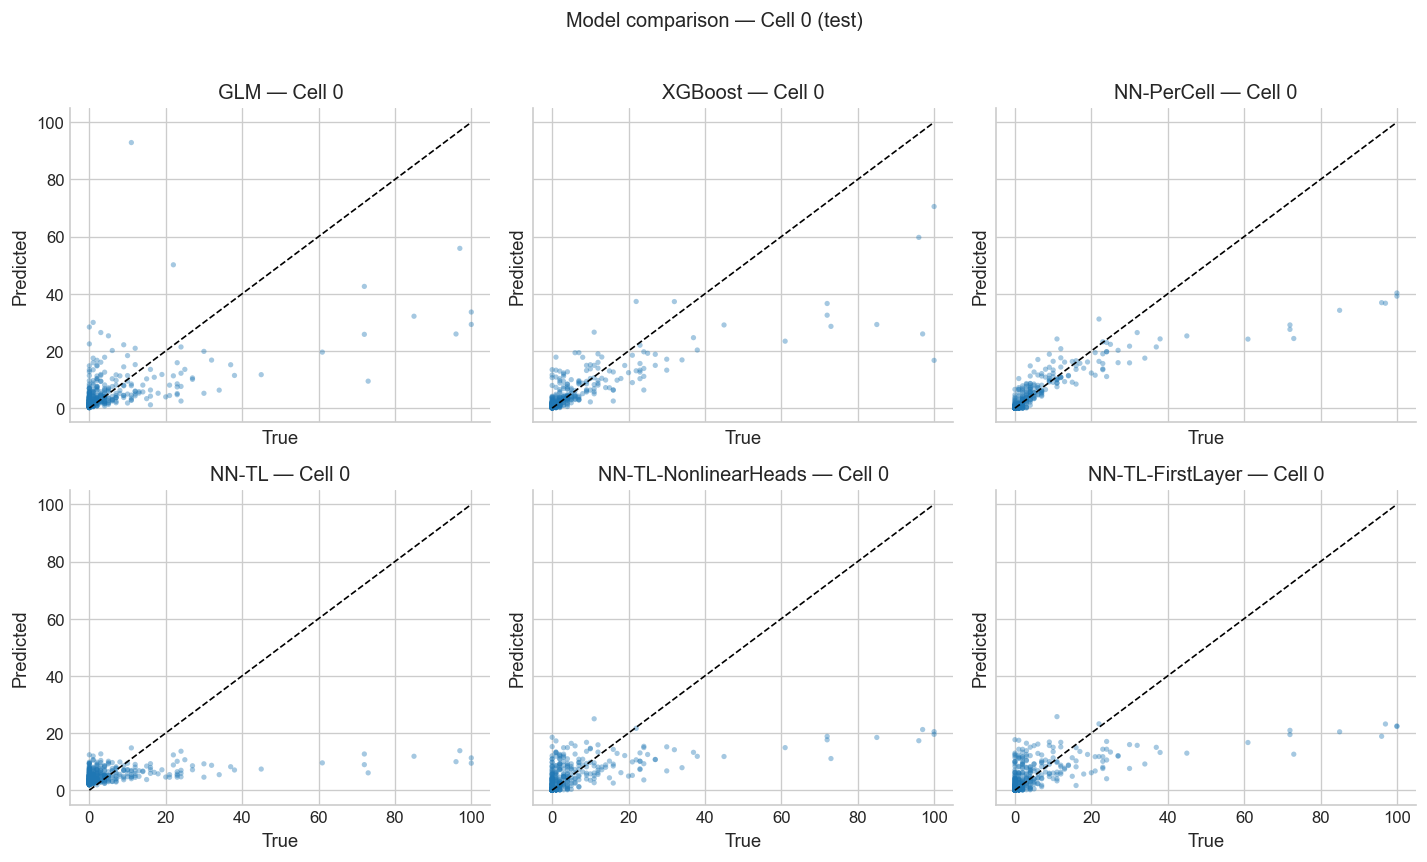

In [ ]:
# Compare models for a single cell
compare_models_for_cell(model_results_gs, cell=0, split="test")

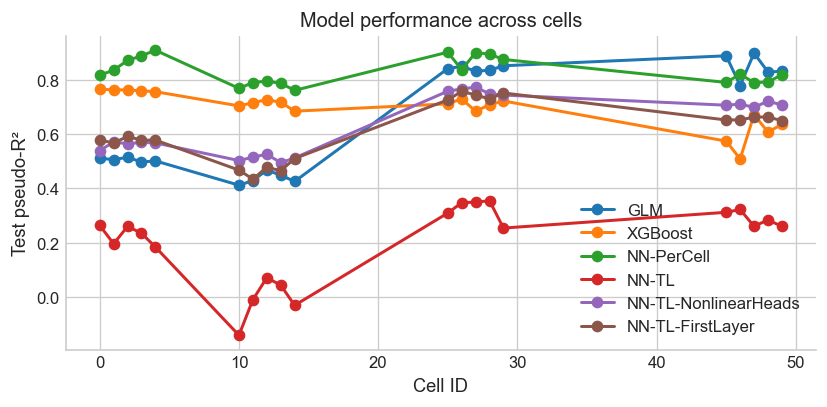

In [ ]:
# Summary of R2 across all cells
compare_r2_across_cells(model_results_gs, split="test")

In [ ]:
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (nn_nogs_results["results"], "NN-PerCell (No GS)"),
    (nn_tl_nogs_results["results"], "NN-TL (No GS)"),
    (nn_tl_nogs_nonlinear["results"], "NN-TL-NonlinearHeads (No GS)"),
    (nn_tl_nogs_firstlayer["results"], "NN-TL-FirstLayer (No GS)"),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [ ]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf = pd.DataFrame(data_rows)
df_test_perf

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell (No GS),NN-TL (No GS),NN-TL-NonlinearHeads (No GS),NN-TL-FirstLayer (No GS)
0,0.0,0.495828,0.787478,0.875081,0.175635,0.529276,0.505706
1,1.0,0.491330,0.776923,0.854058,0.217787,0.493096,0.472530
2,2.0,0.487759,0.777255,0.883703,0.210950,0.529711,0.509169
3,3.0,0.481392,0.781882,0.871340,0.125987,0.517711,0.496485
4,4.0,0.472272,0.763104,0.852012,0.256796,0.530645,0.480934
5,10.0,0.413206,0.690789,0.785400,0.092948,0.551989,0.475529
6,11.0,0.439885,0.710068,0.788271,-0.007019,0.461032,0.473745
7,12.0,0.454806,0.729184,0.805660,-0.010535,0.508298,0.521568
8,13.0,0.438039,0.709677,0.788342,-0.003963,0.528117,0.512678
9,14.0,0.431220,0.694672,0.773453,0.004786,0.555955,0.502588


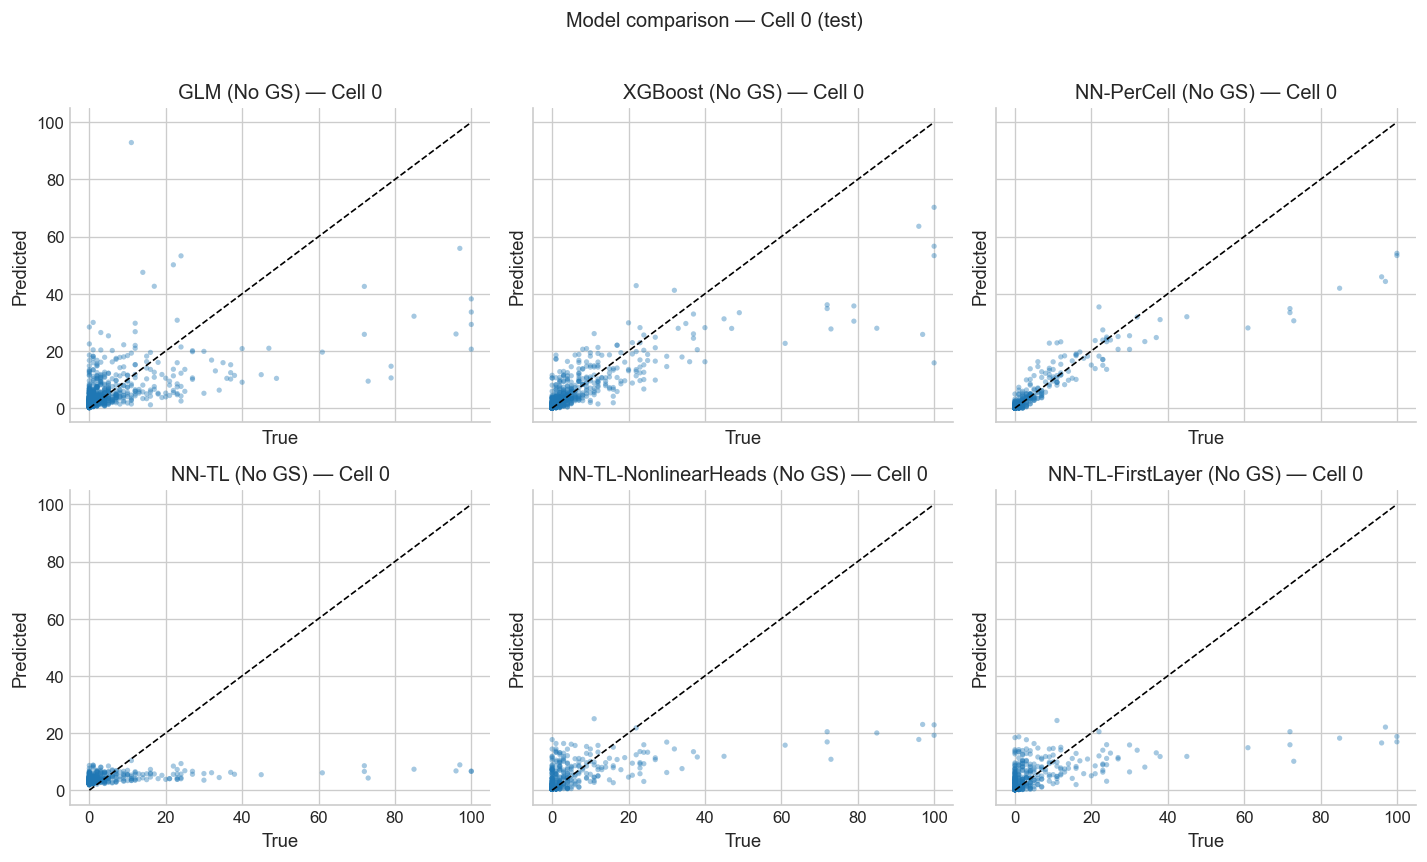

In [ ]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

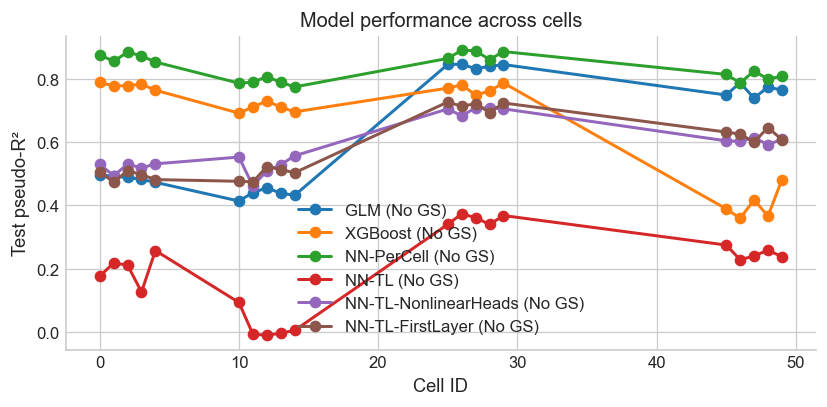

In [ ]:
compare_r2_across_cells(model_results_nogs, split="test")

In [ ]:
# Generate full journal publication-quality plots for all cells and save them
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 21 plots
  ..\data\results\journal\cell_46.0.png
  ..\data\results\journal\cell_47.0.png
  ..\data\results\journal\cell_48.0.png
  ..\data\results\journal\cell_49.0.png
  ..\data\results\journal\r2_summary.png


In [ ]:
# the network architecture diagram is generated automatically for torch models
import os

arch_path = os.path.join("..", "data", "results", "NN-PerCell", "architecture.png")
print("Per-cell NN architecture saved at:", arch_path)

Per-cell NN architecture saved at: ..\data\results\NN-PerCell\architecture.png
